In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
assignments = pd.read_csv("../extraction/assignments.csv", sep=";")
caregivers = pd.read_csv("../extraction/caregivers.csv", sep=";")
clients = pd.read_csv("../extraction/clients.csv", sep=";")

In [7]:
print(len(caregivers))

print(len(caregivers[caregivers["id"].isin(assignments["assignee"])]))

6074
5562


In [44]:
def createDistributedCutDates(caregivers, assignments, distribution):
    """
    Create one cut date per caregiver such that the number of days
    remaining after the cut approximately follows the requested distribution.

    remaining_days = max(endDate) - cutDate
    """

    caregiver_ranges = []

    # ---------------------------------------------------------
    # Determine valid temporal range for every caregiver
    # ---------------------------------------------------------
    for _, caregiver in caregivers.iterrows():

        caregiver_assignments = assignments[
            assignments["assignee"] == caregiver["id"]
        ]

        if caregiver_assignments.empty:
            continue

        start = caregiver_assignments["startDate"].min()
        end = caregiver_assignments["endDate"].max()

        total_days = (end - start).total_seconds() / 86400

        if total_days <= 0:
            continue

        caregiver_ranges.append({
            "caregiverId": caregiver["id"],
            "start": start,
            "end": end,
            "totalDays": total_days
        })

    if not caregiver_ranges:
        return {}

    n = len(caregiver_ranges)

    # Maximum sensible remaining-time range across the population.
    max_days = max(x["totalDays"] for x in caregiver_ranges)

    # ---------------------------------------------------------
    # Generate desired remaining-day targets
    # ---------------------------------------------------------

    if distribution == "equal":
        # Evenly distribute caregivers over the full range.
        #
        # Using bin centers rather than the edges avoids cuts exactly
        # at start/end for most caregivers.
        target_remaining_days = (
            np.arange(n) + 0.5
        ) / n * max_days

    elif distribution == "normal":
        # Center the bell curve around half the available range.
        mean = max_days / 2

        # +/- 3 sigma approximately spans [0, max_days]
        std = max_days / 6

        target_remaining_days = np.random.normal(
            loc=mean,
            scale=std,
            size=n
        )

        target_remaining_days = np.clip(
            target_remaining_days,
            0,
            max_days
        )

    else:
        raise ValueError(
            f"Unknown distributed cut type: {distribution}"
        )

    # Shuffle so long/short remaining times aren't systematically
    # assigned according to caregiver dataframe order.
    np.random.shuffle(target_remaining_days)

    # ---------------------------------------------------------
    # Assign target remaining times to caregivers
    # ---------------------------------------------------------

    result = {}

    for caregiver_data, remaining_days in zip(
        caregiver_ranges,
        target_remaining_days
    ):

        # This caregiver might not have enough history to support the
        # globally requested remaining time.
        remaining_days = min(
            remaining_days,
            caregiver_data["totalDays"]
        )

        cut_date = (
            caregiver_data["end"]
            - pd.Timedelta(days=float(remaining_days))
        )

        result[caregiver_data["caregiverId"]] = cut_date

    return result


def cut(assignments, date):
    assignments_before = assignments[
        assignments["endDate"] <= date
    ].copy()

    assignments_after = assignments[
        assignments["startDate"] >= date
    ].copy()

    overlapping = assignments[
        (assignments["startDate"] < date) &
        (assignments["endDate"] > date)
    ]

    for _, assignment in overlapping.iterrows():
        before_part = assignment.copy()
        before_part["endDate"] = date

        after_part = assignment.copy()
        after_part["startDate"] = date

        assignments_before.loc[len(assignments_before)] = before_part
        assignments_after.loc[len(assignments_after)] = after_part

    return assignments_before, assignments_after



def createTemporalCut(datasets, configuration):

    required = ["caregivers", "assignments", "clients"]

    for dataset in required:
        if dataset not in datasets:
            print(f"{dataset} dataset is required!")
            return


    caregivers = datasets["caregivers"]
    assignments = datasets["assignments"]
    clients = datasets["clients"]


    assignments = assignments.copy()
    assignments["startDate"] = pd.to_datetime(
        assignments["startDate"].astype(str),
        format="%Y%m%d%H%M%S"
    )

    assignments["endDate"] = pd.to_datetime(
        assignments["endDate"].astype(str),
        format="%Y%m%d%H%M%S"
    )

    distributedCutDates = None

    if configuration["cutType"] == "distributed":
        distributedCutDates = createDistributedCutDates(
            caregivers,
            assignments,
            configuration["cutValue"]
        )

    match configuration["cutType"]:
        case "random":
            def getCutDate(caregiver, assignments):
                start  = assignments["endDate"].min()
                end  = assignments["startDate"].max()

                if pd.isna(start) or pd.isna(end) or start >= end:
                    return None

                randomSeconds = np.random.randint(
                    0, 
                    int((end - start).total_seconds())+1
                )

                return start + pd.Timedelta(seconds=randomSeconds)
            
        case "distributed":
            def getCutDate(caregiver, assignments):
                return distributedCutDates.get(caregiver["id"])
            
        case "date":
            def getCutDate(caregiver, assignments):
                date = pd.to_datetime(configuration["cutValue"])

                starts_before = (assignments["startDate"] <= date).any()
                ends_after = (assignments["endDate"] >= date).any()

                if starts_before and ends_after:
                    return date

                return None
            
        case "daysFromStart":
            def getCutDate(caregiver, assignments):
                days = configuration["cutValue"]

                start = assignments["startDate"].min()
                cut_date = start + pd.Timedelta(days=days)

                if cut_date <= assignments["endDate"].max():
                    return cut_date

                return None

        case "daysToEnd":
            def getCutDate(caregiver, assignments):
                days = configuration["cutValue"]

                end = assignments["endDate"].max()
                cut_date = end - pd.Timedelta(days=days)

                if cut_date >= assignments["startDate"].min():
                    return cut_date

                return None
            
        case "ratio":
            def getCutDate(caregiver, assignments):
                ratio = configuration["cutValue"]

                if not 0 <= ratio <= 1:
                    raise ValueError("ratio must be between 0 and 1")

                start = assignments["startDate"].min()
                end = assignments["endDate"].max()

                duration = end - start

                return start + duration * ratio
            
        case _:
            def getCutDate(caregivers, assignments):
                if caregivers["ausgesch-am"] != None:
                    return caregivers["ausgesch-am"]
                else:
                    return assignments["endDate"].max()


    result = {}

    for _, caregiver in caregivers.iterrows():

        caregiverAssignments = assignments[
            assignments["assignee"] == caregiver["id"]
        ]

        if caregiverAssignments.empty:
            continue

        cutDate = getCutDate(
            caregiver,
            caregiverAssignments
        )

        if cutDate is None:
            continue

        assignments_before, assignments_after = cut(
            caregiverAssignments,
            cutDate
        )

        result[caregiver["id"]] = {
            "cutDate": cutDate,
            "startDate" : caregiver["eingestellt-am"],
            "endDate" : caregiver["ausgesch-am"],
            "before": assignments_before,
            "after": assignments_after
        }

    return result

    

In [45]:
datasets = {}

datasets["caregivers"] = caregivers
datasets["clients"] = clients
datasets["assignments"] = assignments





In [46]:
configs = [
    {
        "cutType": "random",
        "cutValue": None
    },
    {
        "cutType": "daysFromStart",
        "cutValue": 365
    },
    {
        "cutType": "daysToEnd",
        "cutValue": 365
    },
    {
        "cutType": "ratio",
        "cutValue": 0.5
    },
    {
        "cutType": "date",
        "cutValue": "20180101000000"
    }
]

cutType: random, cutValue: None
Number of cuts: 4162
Min:    1.8 days
Max:    3240.6 days
Mean:   385.4 days


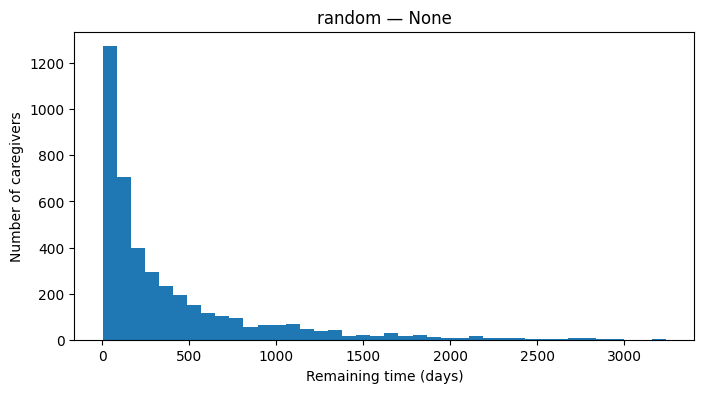

cutType: daysFromStart, cutValue: 365
Number of cuts: 2412
Min:    1.0 days
Max:    3093.0 days
Mean:   865.2 days


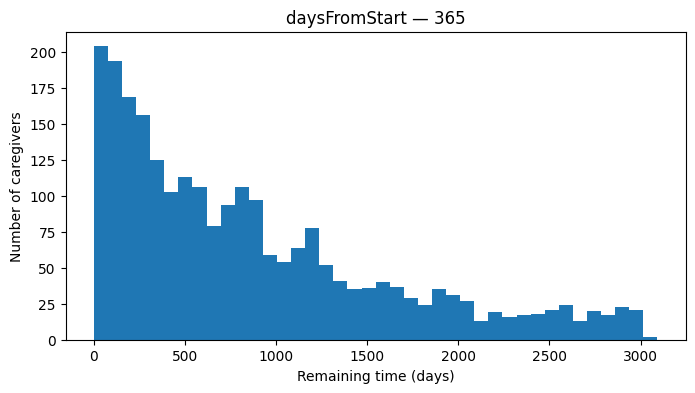

cutType: daysToEnd, cutValue: 365
Number of cuts: 2414
Min:    365.0 days
Max:    365.0 days
Mean:   365.0 days


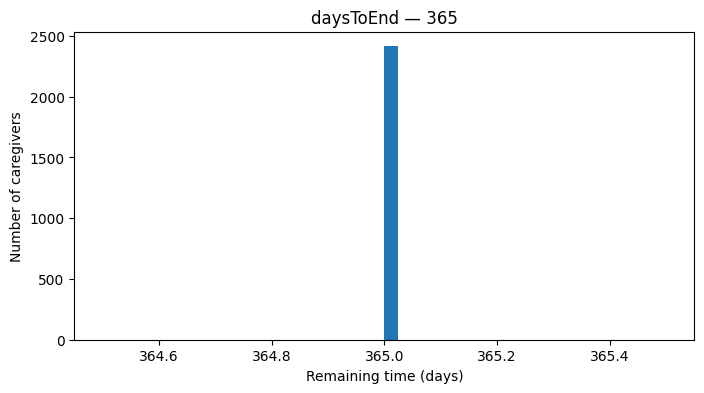

cutType: ratio, cutValue: 0.5
Number of cuts: 5562
Min:    0.0 days
Max:    1729.0 days
Mean:   296.1 days


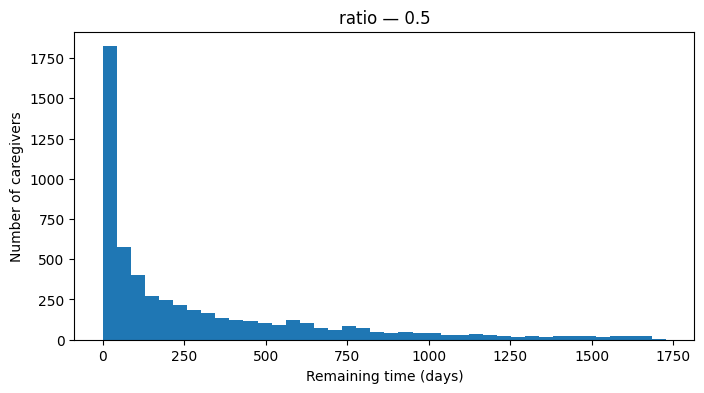

cutType: date, cutValue: 20180101000000
Number of cuts: 327
Min:    3.0 days
Max:    3223.0 days
Mean:   1572.5 days


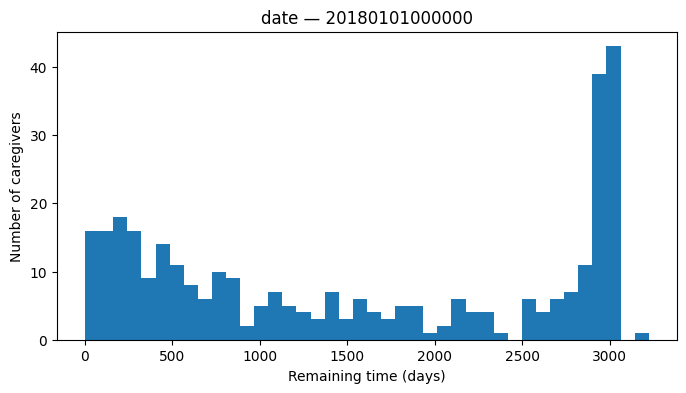

In [ ]:
for config in configs:

    print("=" * 60)
    print(
        f"cutType: {config['cutType']}, "
        f"cutValue: {config['cutValue']}"
    )

    result = createTemporalCut(datasets, config)

    if result is None:
        print("No result")
        continue

    times = []

    for r in result.values():

        if r["after"].empty:
            continue

        time_remaining = (
            r["after"]["endDate"].max()
            - r["cutDate"]
        ).total_seconds() / 86400

        times.append(time_remaining)

    if not times:
        print("No valid cuts")
        continue

    print(f"Number of cuts: {len(times)}")
    print(f"Min:    {min(times):.1f} days")
    print(f"Max:    {max(times):.1f} days")
    print(f"Mean:   {sum(times) / len(times):.1f} days")

    plt.figure(figsize=(8, 4))

    plt.hist(times, bins=40)

    plt.xlabel("Remaining time (days)")
    plt.ylabel("Number of caregivers")
    plt.title(
        f"{config['cutType']} — {config['cutValue']}"
    )
    plt.xticks(
        
    )

    plt.show()

In [ ]:
from dataclasses import dataclass
from typing import Optional, Union

import numpy as np
import pandas as pd


# ============================================================
# Configuration
# ============================================================

@dataclass
class CutConfig:
    """
    Defines the point in a caregiver timeline at which a snapshot
    is created.

    Supported modes
    ---------------

    "random_days"
        Recommended for the main predictive experiment.
        Draws one landmark uniformly between min_days and max_days
        after recruitment. The draw does NOT use the future exit date.

        Example:
            CutConfig(
                mode="random_days",
                min_days=180,
                max_days=730,
                random_state=42
            )

    "days"
        Fixed landmark measured in days after recruitment.

        Example:
            CutConfig(mode="days", value=365)

    "date"
        Fixed calendar date.

        Example:
            CutConfig(mode="date", value="2024-01-01")

    "ratio"
        Retrospective analysis only.
        Uses a fraction of recruitment -> observed_end and therefore
        depends on the future observed end date. Do NOT use this mode
        for the main prospective forecasting experiment.

        Example:
            CutConfig(mode="ratio", value=0.70)

    "full"
        Retrospective analysis only.
        Uses the full observable history up to observed_end.
    """

    mode: str = "random_days"

    # Used by "ratio", "days", and "date".
    value: Optional[Union[float, int, str]] = None

    # Used by "random_days".
    min_days: int = 180
    max_days: int = 730

    # Reproducibility of random landmarks.
    random_state: int = 42


# ============================================================
# Date parsing
# ============================================================

def _parse_caregiver_date(series: pd.Series) -> pd.Series:
    """
    Parses dates such as:
        20190903
        20190903.0
        "20190903"
    """
    cleaned = (
        series
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )

    return pd.to_datetime(
        cleaned,
        format="%Y%m%d",
        errors="coerce"
    )


def _parse_assignment_date(series: pd.Series) -> pd.Series:
    """
    Parses assignment dates such as:
        20160914000000
    """
    cleaned = (
        series
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )

    return pd.to_datetime(
        cleaned,
        format="%Y%m%d%H%M%S",
        errors="coerce"
    )


# ============================================================
# Interval utilities
# ============================================================

def _union_days(intervals):
    """
    Calculates unique covered calendar days.

    This prevents overlapping assignments from counting the
    same workday twice.
    """

    if not intervals:
        return 0

    intervals = sorted(intervals, key=lambda x: x[0])

    merged = []

    current_start, current_end = intervals[0]

    for start, end in intervals[1:]:

        if start <= current_end + pd.Timedelta(days=1):
            current_end = max(current_end, end)

        else:
            merged.append((current_start, current_end))
            current_start, current_end = start, end

    merged.append((current_start, current_end))

    return sum(
        (end - start).days + 1
        for start, end in merged
    )


# ============================================================
# Cutoff calculation
# ============================================================

def _calculate_cutoff(
    recruitment_date,
    observed_end,
    cut: CutConfig,
    rng=None
):
    """
    Calculate a snapshot cutoff.

    Important:
        - random_days, days and date do NOT require knowledge of
          the future exit date to determine the landmark.
        - ratio and full are retrospective modes and should not be
          used as the main forecasting design.
    """

    if cut.mode == "ratio":

        if cut.value is None:
            raise ValueError(
                "For ratio mode, 'value' must be provided."
            )

        ratio = float(cut.value)

        if not 0 < ratio < 1:
            raise ValueError(
                "For ratio mode, value must be > 0 and < 1."
            )

        total_days = (
            observed_end - recruitment_date
        ).days

        return (
            recruitment_date
            + pd.Timedelta(
                days=int(total_days * ratio)
            )
        )

    elif cut.mode == "days":

        if cut.value is None:
            raise ValueError(
                "For days mode, 'value' must be provided."
            )

        days = int(cut.value)

        if days < 0:
            raise ValueError(
                "For days mode, value must be >= 0."
            )

        return (
            recruitment_date
            + pd.Timedelta(days=days)
        )

    elif cut.mode == "random_days":

        if cut.min_days < 0:
            raise ValueError(
                "min_days must be >= 0."
            )

        if cut.max_days < cut.min_days:
            raise ValueError(
                "max_days must be >= min_days."
            )

        if rng is None:
            rng = np.random.default_rng(
                cut.random_state
            )

        landmark_days = int(
            rng.integers(
                low=cut.min_days,
                high=cut.max_days + 1
            )
        )

        return (
            recruitment_date
            + pd.Timedelta(
                days=landmark_days
            )
        )

    elif cut.mode == "date":

        if cut.value is None:
            raise ValueError(
                "For date mode, 'value' must be provided."
            )

        return pd.Timestamp(
            cut.value
        ).normalize()

    elif cut.mode == "full":

        return observed_end

    else:

        raise ValueError(
            "Unknown cut mode "
            f"'{cut.mode}'. "
            "Supported modes are: "
            "'random_days', 'days', 'date', "
            "'ratio', and 'full'."
        )


# ============================================================
# Main function
# ============================================================

def build_caregiver_snapshot_dataset(
    caregivers: pd.DataFrame,
    assignments: pd.DataFrame,
    clients: pd.DataFrame,

    cut: Optional[CutConfig] = None,

    study_end: Optional[str] = None,

    caregiver_id_col: str = "id",
    assignment_caregiver_col: str = "assignee",
    assignment_client_col: str = "clients",
    client_id_col: str = "id",

    recruitment_col: str = "eingestellt-am",
    exit_col: str = "ausgesch-am",
    caregiver_birth_col: str = "dateOfBirth",

    assignment_start_col: str = "startDate",
    assignment_end_col: str = "endDate",

    client_class_col: str = "cluster",

    package_prefix: str = "paket_",

) -> pd.DataFrame:

    """
    Creates one flattened snapshot row per caregiver.

    Features are generated ONLY from assignments visible up to
    the configured cutoff date.

    Returns:
        caregiver master data
        + snapshot metadata
        + survival target
        + work-history features
        + package exposure
        + client-class exposure
    """

    caregivers = caregivers.copy()
    assignments = assignments.copy()
    clients = clients.copy()

    # --------------------------------------------------------
    # Cutoff configuration / reproducible RNG
    # --------------------------------------------------------

    if cut is None:
        cut = CutConfig()

    rng = np.random.default_rng(
        cut.random_state
    )

    # --------------------------------------------------------
    # IDs as strings
    # --------------------------------------------------------

    caregivers[caregiver_id_col] = (
        caregivers[caregiver_id_col]
        .astype(str)
        .str.strip()
    )

    assignments[assignment_caregiver_col] = (
        assignments[assignment_caregiver_col]
        .astype(str)
        .str.strip()
    )

    assignments[assignment_client_col] = (
        assignments[assignment_client_col]
        .astype(str)
        .str.strip()
    )

    clients[client_id_col] = (
        clients[client_id_col]
        .astype(str)
        .str.strip()
    )

    # --------------------------------------------------------
    # Dates
    # --------------------------------------------------------

    caregivers["_recruitment_date"] = (
        _parse_caregiver_date(
            caregivers[recruitment_col]
        )
    )

    caregivers["_exit_date"] = (
        _parse_caregiver_date(
            caregivers[exit_col]
        )
    )

    if caregiver_birth_col in caregivers.columns:
        caregivers["_birth_date"] = (
            _parse_caregiver_date(
                caregivers[caregiver_birth_col]
            )
        )

    assignments["_assignment_start"] = (
        _parse_assignment_date(
            assignments[assignment_start_col]
        )
    )

    assignments["_assignment_end"] = (
        _parse_assignment_date(
            assignments[assignment_end_col]
        )
    )

    # Normalize to calendar days
    assignments["_assignment_start"] = (
        assignments["_assignment_start"].dt.normalize()
    )

    assignments["_assignment_end"] = (
        assignments["_assignment_end"].dt.normalize()
    )

    # --------------------------------------------------------
    # Study end
    # --------------------------------------------------------

    if study_end is None:

        possible_dates = [
            caregivers["_exit_date"].max(),
            assignments["_assignment_end"].max()
        ]

        study_end_date = max(
            d for d in possible_dates
            if pd.notna(d)
        )

    else:

        study_end_date = pd.Timestamp(study_end)

    # --------------------------------------------------------
    # Add client class to assignments
    # --------------------------------------------------------

    client_lookup = clients[
        [
            client_id_col,
            client_class_col
        ]
    ].drop_duplicates(
        subset=[client_id_col]
    )

    assignments = assignments.merge(
        client_lookup,
        left_on=assignment_client_col,
        right_on=client_id_col,
        how="left",
        suffixes=("", "_client")
    )

    # --------------------------------------------------------
    # Package columns
    # --------------------------------------------------------

    package_columns = [
        c for c in assignments.columns
        if c.startswith(package_prefix)
    ]

    # --------------------------------------------------------
    # Possible client classes
    # --------------------------------------------------------

    client_classes = sorted(
        clients[client_class_col]
        .dropna()
        .unique()
    )

    result_rows = []

    # ========================================================
    # One caregiver at a time
    # ========================================================

    for _, caregiver in caregivers.iterrows():

        caregiver_id = caregiver[caregiver_id_col]

        recruitment_date = caregiver["_recruitment_date"]
        exit_date = caregiver["_exit_date"]

        # Cannot construct survival record
        if pd.isna(recruitment_date):
            continue

        # ----------------------------------------------------
        # Event / censoring
        # ----------------------------------------------------

        if (
            pd.notna(exit_date)
            and exit_date <= study_end_date
        ):

            observed_end = exit_date
            event = 1

        else:

            observed_end = study_end_date
            event = 0

        # Invalid chronology
        if observed_end < recruitment_date:
            continue

        # ----------------------------------------------------
        # Snapshot cutoff
        # ----------------------------------------------------

        cutoff = _calculate_cutoff(
            recruitment_date,
            observed_end,
            cut,
            rng=rng
        )

        # The snapshot must occur while the caregiver is still
        # observable. For prospective landmark modes we NEVER
        # move a cutoff backwards to the known exit date, because
        # doing so would reintroduce target leakage.
        if cutoff < recruitment_date:
            continue

        if cut.mode in {
            "random_days",
            "days",
            "date"
        }:
            if cutoff >= observed_end:
                continue

        # ratio/full are retained only for retrospective analyses.
        # They explicitly depend on observed_end.

        # ----------------------------------------------------
        # Snapshot survival targets
        # ----------------------------------------------------

        days_since_recruitment = (
            cutoff - recruitment_date
        ).days

        remaining_observed_days = (
            observed_end - cutoff
        ).days

        # Event after snapshot
        event_after_snapshot = int(
            event == 1 and exit_date > cutoff
        )

        # ----------------------------------------------------
        # Caregiver assignments
        # ----------------------------------------------------

        cg_assignments = assignments[
            assignments[
                assignment_caregiver_col
            ] == caregiver_id
        ].copy()

        # Only assignments which have started before snapshot
        cg_assignments = cg_assignments[
            cg_assignments["_assignment_start"] <= cutoff
        ].copy()

        # Ignore assignments ending before recruitment
        cg_assignments = cg_assignments[
            cg_assignments["_assignment_end"] >= recruitment_date
        ].copy()

        # ----------------------------------------------------
        # Clip assignments to observable snapshot history
        # ----------------------------------------------------

        if not cg_assignments.empty:

            cg_assignments["_visible_start"] = (
                cg_assignments["_assignment_start"]
                .clip(lower=recruitment_date)
            )

            cg_assignments["_visible_end"] = (
                cg_assignments["_assignment_end"]
                .clip(upper=cutoff)
            )

            cg_assignments = cg_assignments[
                cg_assignments["_visible_end"]
                >=
                cg_assignments["_visible_start"]
            ].copy()

            cg_assignments["_visible_days"] = (
                (
                    cg_assignments["_visible_end"]
                    -
                    cg_assignments["_visible_start"]
                ).dt.days
                + 1
            )

        # ----------------------------------------------------
        # Start row with caregiver master data
        # ----------------------------------------------------

        row = caregiver.drop(
            labels=[
                "_recruitment_date",
                "_exit_date",
                "_birth_date"
            ],
            errors="ignore"
        ).to_dict()

        # ----------------------------------------------------
        # Snapshot metadata
        # ----------------------------------------------------

        row.update({

            "snapshot_date":
                cutoff,

            "recruitment_date_clean":
                recruitment_date,

            "exit_date_clean":
                exit_date,

            "study_end":
                study_end_date,

            "snapshot_ratio":
                cut.value
                if cut.mode == "ratio"
                else np.nan,

            "snapshot_mode":
                cut.mode,

            "snapshot_landmark_days":
                days_since_recruitment,

            "snapshot_random_min_days":
                cut.min_days
                if cut.mode == "random_days"
                else np.nan,

            "snapshot_random_max_days":
                cut.max_days
                if cut.mode == "random_days"
                else np.nan,

            "snapshot_random_state":
                cut.random_state
                if cut.mode == "random_days"
                else np.nan,

            "days_since_recruitment":
                days_since_recruitment,

            # TARGET / SURVIVAL VARIABLES
            "target_event":
                event_after_snapshot,

            "target_remaining_days":
                remaining_observed_days,

            "target_observed_end":
                observed_end

        })

        # ----------------------------------------------------
        # Age features
        # ----------------------------------------------------

        if (
            "_birth_date" in caregiver.index
            and
            pd.notna(caregiver["_birth_date"])
        ):

            birth = caregiver["_birth_date"]

            row["age_at_recruitment"] = (
                recruitment_date - birth
            ).days / 365.25

            row["age_at_snapshot"] = (
                cutoff - birth
            ).days / 365.25

        # ====================================================
        # No assignments yet
        # ====================================================

        if cg_assignments.empty:

            row.update({

                "number_assignments": 0,

                "number_unique_clients": 0,

                "workdays": 0,

                "offworkdays":
                    days_since_recruitment + 1,

                "work_ratio": 0.0,

                "mean_assignment_length": 0.0,

                "median_assignment_length": 0.0,

                "min_assignment_length": 0.0,

                "max_assignment_length": 0.0,

                "std_assignment_length": 0.0,

                "mean_offwork_length": np.nan,

                "days_since_last_assignment": np.nan,

                "repeat_client_ratio": 0.0

            })

            for cls in client_classes:

                row[f"days_client_class_{cls}"] = 0

                row[f"share_client_class_{cls}"] = 0.0

            for package in package_columns:

                safe_name = (
                    package
                    .replace("paket_", "")
                    .replace(" ", "_")
                    .replace("-", "_")
                )

                row[f"days_package_{safe_name}"] = 0

                row[f"share_package_{safe_name}"] = 0.0

            result_rows.append(row)

            continue

        # ====================================================
        # Work history
        # ====================================================

        intervals = list(
            zip(
                cg_assignments["_visible_start"],
                cg_assignments["_visible_end"]
            )
        )

        workdays = _union_days(intervals)

        total_observed_days = (
            cutoff - recruitment_date
        ).days + 1

        offworkdays = max(
            total_observed_days - workdays,
            0
        )

        lengths = cg_assignments["_visible_days"]

        row["number_assignments"] = len(
            cg_assignments
        )

        row["number_unique_clients"] = (
            cg_assignments[
                assignment_client_col
            ].nunique()
        )

        row["workdays"] = workdays

        row["offworkdays"] = offworkdays

        row["work_ratio"] = (
            workdays / total_observed_days
            if total_observed_days > 0
            else np.nan
        )

        row["mean_assignment_length"] = (
            lengths.mean()
        )

        row["median_assignment_length"] = (
            lengths.median()
        )

        row["min_assignment_length"] = (
            lengths.min()
        )

        row["max_assignment_length"] = (
            lengths.max()
        )

        row["std_assignment_length"] = (
            lengths.std()
        )

        # ----------------------------------------------------
        # Assignment gaps
        # ----------------------------------------------------

        ordered = cg_assignments.sort_values(
            "_visible_start"
        )

        gaps = []

        previous_end = None

        for _, assignment in ordered.iterrows():

            start = assignment["_visible_start"]
            end = assignment["_visible_end"]

            if previous_end is not None:

                gap = (
                    start - previous_end
                ).days - 1

                if gap >= 0:
                    gaps.append(gap)

            previous_end = max(
                previous_end,
                end
            ) if previous_end is not None else end

        row["mean_offwork_length"] = (
            np.mean(gaps)
            if gaps
            else 0.0
        )

        row["median_offwork_length"] = (
            np.median(gaps)
            if gaps
            else 0.0
        )

        row["max_offwork_length"] = (
            max(gaps)
            if gaps
            else 0.0
        )

        last_assignment_end = (
            ordered["_visible_end"].max()
        )

        row["days_since_last_assignment"] = max(
            (cutoff - last_assignment_end).days,
            0
        )

        # ----------------------------------------------------
        # Client repetition / stability
        # ----------------------------------------------------

        client_sequence = ordered[
            assignment_client_col
        ].tolist()

        seen = set()
        repeat_count = 0

        for client in client_sequence:

            if client in seen:
                repeat_count += 1

            seen.add(client)

        row["repeat_client_ratio"] = (
            repeat_count / len(client_sequence)
            if client_sequence
            else 0.0
        )

        # ====================================================
        # Client-class exposure
        # ====================================================

        total_classified_days = 0

        class_days_dict = {}

        for cls in client_classes:

            cls_days = cg_assignments.loc[
                cg_assignments[
                    client_class_col
                ] == cls,
                "_visible_days"
            ].sum()

            cls_days = int(cls_days)

            class_days_dict[cls] = cls_days

            total_classified_days += cls_days

            row[
                f"days_client_class_{cls}"
            ] = cls_days

        for cls in client_classes:

            row[
                f"share_client_class_{cls}"
            ] = (
                class_days_dict[cls]
                /
                total_classified_days
                if total_classified_days > 0
                else 0.0
            )

        row["classified_client_days"] = (
            total_classified_days
        )

        # ----------------------------------------------------
        # Average client care intensity
        # ----------------------------------------------------

        numeric_classes = []

        for cls, days in class_days_dict.items():

            try:

                numeric_classes.append(
                    (float(cls), days)
                )

            except (TypeError, ValueError):

                pass

        if numeric_classes and total_classified_days:

            row["average_client_class"] = (
                sum(
                    cls * days
                    for cls, days
                    in numeric_classes
                )
                /
                total_classified_days
            )

        else:

            row["average_client_class"] = np.nan

        # ----------------------------------------------------
        # Current / previous client class
        # ----------------------------------------------------

        class_history = (
            ordered[
                [
                    "_visible_start",
                    client_class_col
                ]
            ]
            .dropna(
                subset=[client_class_col]
            )
        )

        if len(class_history) >= 1:

            row["current_client_class"] = (
                class_history.iloc[-1][
                    client_class_col
                ]
            )

        else:

            row["current_client_class"] = np.nan

        if len(class_history) >= 2:

            row["previous_client_class"] = (
                class_history.iloc[-2][
                    client_class_col
                ]
            )

            try:

                row["client_class_change"] = (
                    float(
                        row[
                            "current_client_class"
                        ]
                    )
                    -
                    float(
                        row[
                            "previous_client_class"
                        ]
                    )
                )

            except Exception:

                row["client_class_change"] = np.nan

        else:

            row["previous_client_class"] = np.nan
            row["client_class_change"] = np.nan

        # ====================================================
        # Package exposure
        # ====================================================

        for package in package_columns:

            safe_name = (
                package
                .replace("paket_", "")
                .replace(" ", "_")
                .replace("-", "_")
            )

            package_values = (
                pd.to_numeric(
                    cg_assignments[package],
                    errors="coerce"
                )
                .fillna(0)
            )

            days = (
                cg_assignments["_visible_days"]
                *
                package_values
            ).sum()

            row[
                f"days_package_{safe_name}"
            ] = days

            row[
                f"share_package_{safe_name}"
            ] = (
                days / workdays
                if workdays > 0
                else 0.0
            )

        result_rows.append(row)

    result = pd.DataFrame(result_rows)

    return result

### Cutoff modes\n
\n
The snapshot generator now supports several cutoff strategies:\n
\n
- `random_days`: **recommended main forecasting setup**. Draws one landmark between `min_days` and `max_days` after recruitment without using the future exit date.\n
- `days`: fixed landmark, e.g. 365 days after recruitment.\n
- `date`: fixed calendar prediction date.\n
- `ratio`: retrospective sensitivity analysis only because the cutoff depends on the eventual observed end.\n
- `full`: retrospective analysis only.\n
\n
For `random_days`, `days`, and `date`, caregivers who are no longer observable at the requested landmark are excluded rather than moving the cutoff backwards to their exit date. This prevents future-information leakage.\n

In [5]:
# Recommended main experiment:
# one reproducible random prediction landmark per caregiver,
# sampled independently of the future exit date.
snapshot_df = build_caregiver_snapshot_dataset(
    caregivers=caregivers[caregivers["id"].isin(assignments["assignee"])],
    assignments=assignments,
    clients=clients,

    cut=CutConfig(
        mode="random_days",
        min_days=30,
        max_days=730,
        random_state=42
    ),

    study_end="2026-08-31",

    client_class_col="cluster"
)

print(snapshot_df["snapshot_landmark_days"].describe())
print(snapshot_df["snapshot_mode"].value_counts())


count    3578.000000
mean      330.129681
std       203.646665
min        30.000000
25%       148.000000
50%       305.500000
75%       496.000000
max       730.000000
Name: snapshot_landmark_days, dtype: float64
snapshot_mode
random_days    3578
Name: count, dtype: int64


In [13]:
snapshot_df.to_csv("snapshot.csv", sep=";")